### [ 블러링- 평균 블러 ] <hr>
- 커널/ 마스크/ 필터/ 윈도우라고 하는 작은 행렬을 사용해서 이미지 픽셀값 조절
- 이미지 노이즈 블러링
- 이미지 경계 뚜렷하게 하기
- 커널 종류에 따라 기능이 정해짐

In [2]:
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils
import importlib
import cv_utils

importlib.reload(cv_utils)

from cv_utils import printPlotImage
importlib.reload(cv_utils)


<module 'cv_utils' from 'C:\\KDT14\\7_CV\\cv_utils.py'>

(np.float64(-0.5), np.float64(399.5), np.float64(443.5), np.float64(-0.5))

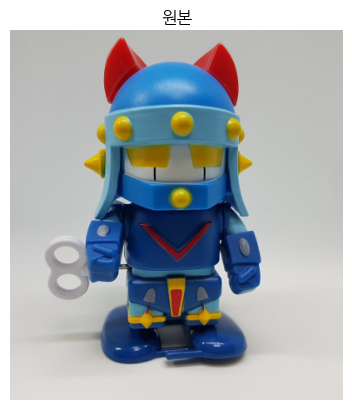

In [9]:
## ================================================
## 데이터 준비
## ================================================


IMG_FILE= '../Images/taekwonv1.jpg'
img= cv2.imread(IMG_FILE)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("원본")
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(443.5), np.float64(-0.5))

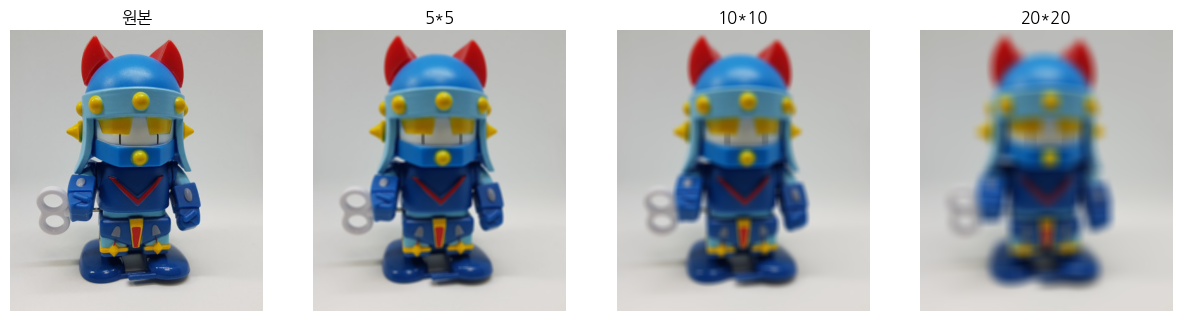

In [16]:
blurNP=cv2.blur(img, (5, 5))
blurNP1=cv2.blur(img, (10, 10)) 
blurNP2=cv2.blur(img, (20, 20)) 
plt.figure(figsize=(15, 5))



plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
plt.title("원본")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(blurNP, cv2.COLOR_RGB2BGR))
plt.title("5*5")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(blurNP1, cv2.COLOR_RGB2BGR))
plt.title("10*10")
plt.axis("off")


plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(blurNP2, cv2.COLOR_RGB2BGR))
plt.title("20*20")
plt.axis("off")


### [ 가우시안 블러 ] <hr>

- 가중치에 따른 값을 가지는 커널
- 중심 픽셀을 기준으로 다른 가중치 값 설정한 커널 사용


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

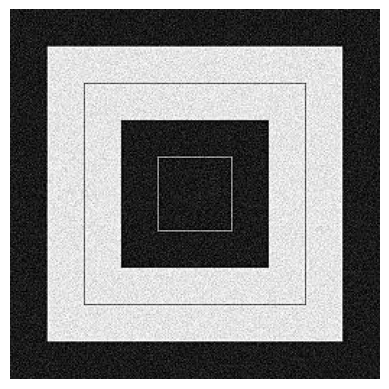

In [24]:
## 

IMG_FILE= '../Images/gaussian_noise.jpg'
img= cv2.imread(IMG_FILE)

plt.imshow(img)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
plt.axis("off")

In [29]:
## ---------------------------------------
## 방법1) 커널 + 컨볼루션 
## ---------------------------------------
## 커널 3*3
kernel= np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])

kernel= np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])* 1/16


kernel
conblur= cv2.filter2D(img, -1, kernel)



(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

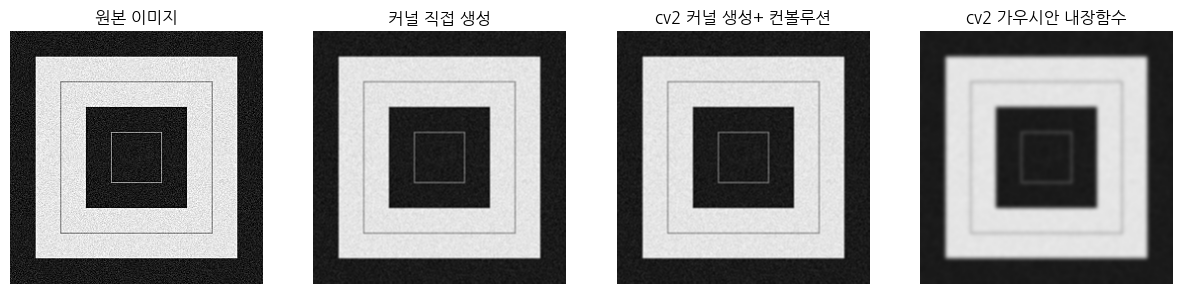

In [ ]:

## ---------------------------------------
## 방법2) cv2. 커널 생성+ 컨볼루션
## ---------------------------------------
gkenel=cv2.getGaussianKernel(3, 0)
conblur2= cv2.filter2D(img, -1, gkenel*gkenel.T)



## ---------------------------------------
## 방법2) cv2.가우시안 블러함수
## ---------------------------------------

conblur3= cv2.GaussianBlur(img, (11,11), 0)




plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("원본 이미지")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(conblur, cv2.COLOR_RGB2BGR))
plt.title("커널 직접 생성")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(conblur2)
plt.title("cv2 커널 생성+ 컨볼루션")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(conblur3)
plt.title("cv2 가우시안 내장함수")
plt.axis("off")
